In [2]:
# Load necessary libraries
if (!require(gdpc)) {
  install.packages("gdpc")
}
library(gdpc)
library(readr)

# Load the data, excluding the Date column
data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv")

# Convert data to matrix form (excluding the Date column)
data_matrix <- as.matrix(data[,-1])

# Standardize the data (optional, depending on the analysis)
data_standardized <- scale(data_matrix)


Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


In [ ]:

# Apply Generalized Dynamic Principal Components (GDPC)
# Here, we only need to specify `Z` (data) and `k` (number of lags)
gdpc_result <- gdpc(Z = data_standardized, k = 1)

# Print and view the results
print(gdpc_result)

# Plot the proportion of variance explained
plot(gdpc_result$expart, type = "b", main = "Proportion of Variance Explained by GDPC",
     xlab = "Number of Lags", ylab = "Explained Variance")

# Plot the dynamic principal component
plot(gdpc_result$f, type = "l", col = "blue", lwd = 2,
     main = "First Generalized Dynamic Principal Component",
     xlab = "Time", ylab = "Component Value")


In [11]:
# Create a script called "gdpc_analysis.R"
cat("
# Load necessary libraries
if (!require(gdpc)) {
  install.packages('gdpc')
}
library(gdpc)
library(readr)

# Define function to run GDPC analysis
run_gdpc_analysis <- function(input_file, output_file, k) {
  # Read the CSV file into R
  data <- read_csv(input_file)
  
  # Convert data to matrix form (excluding the Date column)
  data_matrix <- as.matrix(data[,-1])
  
  # Standardize the data
  data_standardized <- scale(data_matrix)
  
  # Apply Generalized Dynamic Principal Components (GDPC) with specified lags
  gdpc_result <- gdpc(Z = data_standardized, k = k)
  
  # Save the components and results
  saveRDS(gdpc_result, file = output_file)
  
  # Print summary and completion message
  print(paste('GDPC analysis with', k, 'lags completed. Results saved to', output_file))
}

# Parse command line arguments for input file, output file, and number of lags
args <- commandArgs(trailingOnly = TRUE)
input_file <- args[1]
output_file <- args[2]
k <- as.numeric(args[3])

# Run the analysis with the specified arguments
run_gdpc_analysis(input_file, output_file, k)
", file = "gdpc_analysis.R")


In [20]:
# Convert data to matrix form, excluding the Date column
data_matrix <- as.matrix(data[,-1])  # Exclude the Date column

# Standardize the data (if not already standardized)
data_standardized <- scale(data_matrix)

# Check the dimensions and first few rows of the matrix
cat("Data matrix dimensions:", dim(data_matrix), "\n")
head(data_standardized)


Data matrix dimensions: 15706 17 


Niño 3,NAO,Niño 1+2,WHWP,GMT,ONI,PNA,NOI,WP,Niño 3.4,Solar Flux,AMO,ESPI,TSA,Niño 4,TNA,SOI
0.4907329,-1.3914844,-0.1659622,-0.5948051,-0.9568839,0.6993548,-1.06114127,-1.780296,-1.677843,0.6924244,1.853918,-0.2471346,-0.6915090,-1.155251,0.7019734,0.5476266,0.3279865
0.4781091,-1.2525261,-0.1912522,-0.5847657,-0.9465834,0.6973208,-0.65898781,-2.068213,-1.694176,0.6775297,1.894592,-0.2450107,-0.7434463,-1.193198,0.7109273,0.6014069,0.3490948
0.4654252,-1.1234969,-0.2148168,-0.5757038,-0.9366719,0.6950011,-0.28324453,-2.334411,-1.705222,0.6628791,1.931113,-0.2443098,-0.7896789,-1.229585,0.7190798,0.6503059,0.3680625
0.4526882,-1.0041079,-0.2366947,-0.5675928,-0.9271442,0.6924054,0.06676091,-2.579437,-1.711144,0.6484689,1.963602,-0.2449811,-0.8303772,-1.264434,0.7264486,0.6944638,0.3849387
0.4399055,-0.8940703,-0.2569243,-0.5604058,-0.9179952,0.6895435,0.39170084,-2.803838,-1.712103,0.6342958,1.992178,-0.2469737,-0.8657111,-1.297771,0.7330514,0.7340206,0.3997724
0.4270840,-0.7930952,-0.2755440,-0.5541162,-0.9092196,0.6864253,0.69224760,-3.008162,-1.708262,0.6203564,2.016961,-0.2502371,-0.8958508,-1.329617,0.7389062,0.7691163,0.4126127


In [21]:
# Set parameters for Dynamic PCA using freqdom
lags <- 1  # Number of lags to include in the dynamic PCA
n_components <- 1  # Number of dynamic principal components to compute

# Apply Dynamic PCA using freqdom
dpca_result <- dpca(data_standardized, q = lags, Ndpc = n_components)

# Print and inspect the result summary
print(dpca_result)


In [18]:
# Load necessary libraries
library(gdpc)
library(fda.usc)
library(ggplot2)
library(gridExtra)

# Load each stored result object
gdpc_result_lag1 <- readRDS("gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("gdpc_result_lag365.rds")

freqdom_result_lag1 <- readRDS("freqdom_pc1_lag1.rds")
freqdom_result_lag5 <- readRDS("freqdom_pc1_lag5.rds")
freqdom_result_lag10 <- readRDS("freqdom_pc1_lag10.rds")

fnets_result <- readRDS("fnets_analysis_result.rds")

fda_usc_fpca_result <- readRDS("fda_usc_fpca_result.rds")

# If you have results from scikit-fda and they are stored in .rds format
# scikit_fd_result <- readRDS("scikit_fd_result.rds")


Loading required package: fda

Loading required package: splines

Loading required package: fds

Loading required package: rainbow

Loading required package: MASS

Loading required package: pcaPP

Loading required package: RCurl

Loading required package: deSolve


Attaching package: ‘fda’


The following object is masked from ‘package:graphics’:

    matplot


Loading required package: mgcv

Loading required package: nlme

This is mgcv 1.9-1. For overview type 'help("mgcv-package")'.

 fda.usc is running sequentially usign foreach package
 Please, execute ops.fda.usc() once to run in local parallel mode
 Deprecated functions: min.basis, min.np, anova.hetero, anova.onefactor, anova.RPm
 New functions: optim.basis, optim.np, fanova.hetero, fanova.onefactor, fanova.RPm
----------------------------------------------------------------------------------




In [19]:
# Function to retrieve metrics from gdpc results
retrieve_gdpc_metrics <- function(gdpc_result) {
  metrics <- list(
    MSE = gdpc_result$mse,              # Mean Squared Error
    ExplainedVariance = gdpc_result$expart, # Explained variance
    NumberLags = gdpc_result$k,           # Number of lags
    Converged = gdpc_result$conv,         # Convergence status
    Iterations = gdpc_result$niter        # Number of iterations
  )
  return(metrics)
}

# Retrieve metrics for each GDPC result
metrics_lag1 <- retrieve_gdpc_metrics(gdpc_result_lag1)
metrics_lag5 <- retrieve_gdpc_metrics(gdpc_result_lag5)
metrics_lag10 <- retrieve_gdpc_metrics(gdpc_result_lag10)
metrics_lag365 <- retrieve_gdpc_metrics(gdpc_result_lag365)

# Print the metrics for comparison
cat("Metrics for Lag 1:\n")
print(metrics_lag1)

cat("\nMetrics for Lag 5:\n")
print(metrics_lag5)

cat("\nMetrics for Lag 10:\n")
print(metrics_lag10)

cat("\nMetrics for Lag 365:\n")
print(metrics_lag365)


Metrics for Lag 1:
$MSE
[1] 0.503052

$ExplainedVariance
[1] 0.496948

$NumberLags
[1] 1

$Converged
[1] TRUE

$Iterations
[1] 61


Metrics for Lag 5:
$MSE
[1] 0.558543

$ExplainedVariance
[1] 0.441457

$NumberLags
[1] 5

$Converged
[1] TRUE

$Iterations
[1] 37


Metrics for Lag 10:
$MSE
[1] 0.5433093

$ExplainedVariance
[1] 0.4566907

$NumberLags
[1] 10

$Converged
[1] TRUE

$Iterations
[1] 50


Metrics for Lag 365:
$MSE
[1] 0.3946979

$ExplainedVariance
[1] 0.6053021

$NumberLags
[1] 365

$Converged
[1] TRUE

$Iterations
[1] 92



In [8]:
# Load required libraries
install.packages("ggplot2")
install.packages("gridExtra")
library(ggplot2)
library(gridExtra)

# Function to plot GDPC results
plot_gdpc <- function(gdpc_result, lag) {
  ggplot() + 
    geom_line(aes(y = gdpc_result$f, x = 1:length(gdpc_result$f))) +
    ggtitle(paste("GDPC First Principal Component (Lag", lag, ")")) +
    xlab("Time") +
    ylab("First Principal Component")
}

# Function to plot Freqdom results
plot_freqdom <- function(freqdom_result, lag) {
  # Check if freqdom_result is a vector (atomic) or list with 'f'
  if (is.atomic(freqdom_result)) {
    pc1 <- freqdom_result  # Use freqdom_result directly as it's a vector
  } else if (is.list(freqdom_result) && !is.null(freqdom_result$f)) {
    pc1 <- freqdom_result$f[1, ]  # Assuming we want the first component if it's a list
  } else {
    stop("Unexpected structure for freqdom_result.")
  }

  ggplot() + 
    geom_line(aes(y = pc1, x = 1:length(pc1))) +
    ggtitle(paste("Freqdom First Principal Component (Lag", lag, ")")) +
    xlab("Time") +
    ylab("First Principal Component")
}

# Summarize and visualize fnets result (Sigma_x matrix heatmap)
summarize_fnets <- function(fnets_result) {
  # Extract Sigma_x (first slice)
  Sigma_x_first_slice <- fnets_result$spec$Sigma_x[,,1]
  
  # Print first 5x5 of Sigma_x
  cat("First 5x5 elements of Sigma_x (first slice):\n")
  print(Re(Sigma_x_first_slice[1:5, 1:5]))
  
  # Visualize Sigma_x as a heatmap
  heatmap(abs(Re(Sigma_x_first_slice)), main = "Heatmap of Sigma_x (First Slice)", symm = TRUE)
}

# Function to plot FPCA results from fda.usc
plot_fda_usc_fpca <- function(fpca_result) {
  plot(fpca_result$fdataobj, main = "FPCA Mean Function (FDA-USC)")
  lines(fpca_result$mean, col = 'red')
}

# Example of how to call these functions
# Load your saved RDS files for each model
gdpc_result_lag1 <- readRDS("gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("gdpc_result_lag365.rds")

freqdom_result_lag1 <- readRDS("freqdom_pc1_lag1_freq.rds")
freqdom_result_lag5 <- readRDS("freqdom_pc1_lag5_freq.rds")
freqdom_result_lag10 <- readRDS("freqdom_pc1_lag10_freq.rds")

fnets_result <- readRDS("fnets_analysis_result.rds")
fda_usc_fpca_result <- readRDS("fda_usc_fpca_result.rds")

# Plot GDPC results
gdpc_plot1 <- plot_gdpc(gdpc_result_lag1, 1)
gdpc_plot5 <- plot_gdpc(gdpc_result_lag5, 5)
gdpc_plot10 <- plot_gdpc(gdpc_result_lag10, 10)
gdpc_plot365 <- plot_gdpc(gdpc_result_lag365, 365)

# Plot Freqdom results
freqdom_plot1 <- plot_freqdom(freqdom_result_lag1, 1)
freqdom_plot5 <- plot_freqdom(freqdom_result_lag5, 5)
freqdom_plot10 <- plot_freqdom(freqdom_result_lag10, 10)


Installing package into ‘/home/jaguir26/R/x86_64-redhat-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)



Installing package into ‘/home/jaguir26/R/x86_64-redhat-linux-gnu-library/4.4’
(as ‘lib’ is unspecified)



In [ ]:

# Summarize and visualize Fnets results
summarize_fnets(fnets_result)

# Plot FPCA result from FDA-USC
plot_fda_usc_fpca(fda_usc_fpca_result)

# Arrange GDPC and Freqdom plots side by side for comparison
grid.arrange(
  gdpc_plot1, gdpc_plot5, gdpc_plot10,
  freqdom_plot1, freqdom_plot5, freqdom_plot10,
  ncol = 3
)


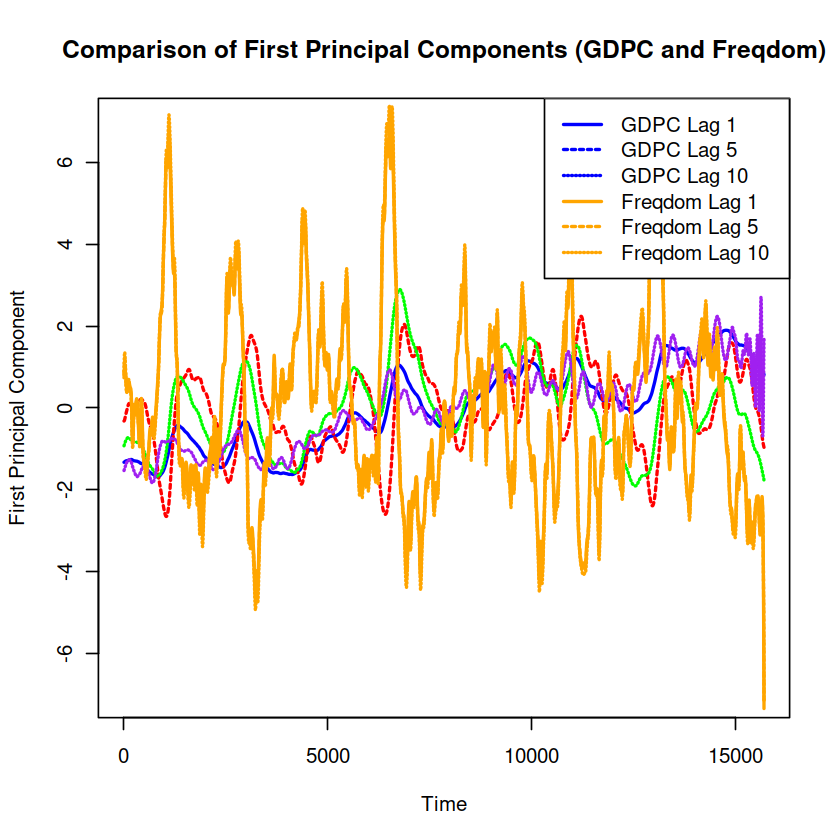

In [18]:
# Assuming the results from all lags are already loaded

# Extract first principal components for GDPC and Freqdom
gdpc_pc1_lag1 <- gdpc_result_lag1$f
gdpc_pc1_lag5 <- gdpc_result_lag5$f
gdpc_pc1_lag10 <- gdpc_result_lag10$f
gdpc_pc1_lag365 <- gdpc_result_lag365$f

freqdom_pc1_lag1 <- freqdom_result_lag1  # Freqdom results are vectors, not lists
freqdom_pc1_lag5 <- freqdom_result_lag5
freqdom_pc1_lag10 <- freqdom_result_lag10

# Create a time index (assuming all have the same length)
time_index <- seq_along(gdpc_pc1_lag1)

# Plot the first component for GDPC and Freqdom in the same plot
# plot(time_index, gdpc_pc1_lag1, type = "l", col = "blue", lwd = 2, ylim = range(c(gdpc_pc1_lag1, gdpc_pc1_lag5, gdpc_pc1_lag10, 
#                                                                                   freqdom_pc1_lag1, freqdom_pc1_lag5, freqdom_pc1_lag10)),
#      main = "Comparison of First Principal Components (GDPC and Freqdom)", xlab = "Time", ylab = "First Principal Component")
plot(time_index, gdpc_pc1_lag1, type = "l", col = "blue", lwd = 2, ylim = c(-7,7),
main = "Comparison of First Principal Components (GDPC and Freqdom)", xlab = "Time", ylab = "First Principal Component")
lines(time_index, gdpc_pc1_lag5, col = "red", lwd = 2, lty = 2)
lines(time_index, gdpc_pc1_lag10, col = "green", lwd = 2, lty = 3)
lines(time_index, gdpc_pc1_lag365, col = "purple", lwd = 2, lty = 3)

lines(time_index, freqdom_pc1_lag1, col = "orange", lwd = 2)
lines(time_index, freqdom_pc1_lag5, col = "orange", lwd = 2, lty = 2)
lines(time_index, freqdom_pc1_lag10, col = "orange", lwd = 2, lty = 3)

# Add a legend
legend("topright", legend = c("GDPC Lag 1", "GDPC Lag 5", "GDPC Lag 10", 
                              "Freqdom Lag 1", "Freqdom Lag 5", "Freqdom Lag 10"), 
       col = c("blue", "blue", "blue", "orange", "orange", "orange"), 
       lty = c(1, 2, 3, 1, 2, 3), lwd = 2)


In [25]:
# For GDPC: You may have this information in gdpc_result (depends on the output structure)
gdpc_var_lag1 <- gdpc_result_lag1$expart  # Check for explained variance or use other criteria
gdpc_var_lag5 <- gdpc_result_lag5$expart
gdpc_var_lag10 <- gdpc_result_lag10$expart

# For Freqdom: You may need to calculate variance explained if it's not directly available.
# Suppose you have to compute it manually:
freqdom_var_lag1 <- var(freqdom_result_lag1) / sum(var(freqdom_result_lag1))
freqdom_var_lag5 <- var(freqdom_result_lag5) / sum(var(freqdom_result_lag5))
freqdom_var_lag10 <- var(freqdom_result_lag10) / sum(var(freqdom_result_lag10))

# Display explained variance for comparison
cat("Explained Variance (GDPC):\n")
cat("Lag 1: ", gdpc_var_lag1, "\n")
cat("Lag 5: ", gdpc_var_lag5, "\n")
cat("Lag 10: ", gdpc_var_lag10, "\n\n")

cat("Explained Variance (Freqdom):\n")
cat("Lag 1: ", freqdom_var_lag1, "\n")
cat("Lag 5: ", freqdom_var_lag5, "\n")
cat("Lag 10: ", freqdom_var_lag10, "\n")


Explained Variance (GDPC):
Lag 1:  0.496948 
Lag 5:  0.441457 
Lag 10:  0.4566907 

Explained Variance (Freqdom):
Lag 1:  1 
Lag 5:  1 
Lag 10:  1 


[1] "Running DPCA with 1 lags..."
List of 5
 $ spec.density:List of 2
  ..$ operators: cplx [1:5, 1:5, 1:2001] 0.71034+3.08e-33i -0.20278+2.02e-17i 0.00763-5.08e-18i ...
  .. ..- attr(*, "dimnames")=List of 3
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : chr [1:2001] "frequency -3.14159265358979" "frequency -3.1384510609362" "frequency -3.13530946828261" "frequency -3.13216787562902" ...
  ..$ freq     : num [1:2001] -3.14 -3.14 -3.14 -3.13 -3.13 ...
  ..- attr(*, "class")= chr "freqdom"
 $ filters     :List of 2
  ..$ operators: num [1:5, 1:5, 1:3] 0.1747 -0.0398 0.0486 0.0632 -0.0998 ...
  .. ..- attr(*, "dimnames")=List of 3
  .. .. ..$ : NULL
  .. .. ..$ : NULL
  .. .. ..$ : chr [1:3] "lag -1" "lag 0" "lag 1"
  ..$ lags     : int [1:3] -1 0 1
  ..- attr(*, "class")= chr "timedom"
 $ scores      : num [1:100, 1:5] -3.332 -3.122 -0.996 0.468 0.32 ...
 $ var         : num [1:5] 0.3476 0.2322 0.1856 0.1355 0.0991
 $ Xhat        : num [1:100, 1:5] -2.848 -2.867 -0.838 -0.638 -0.22

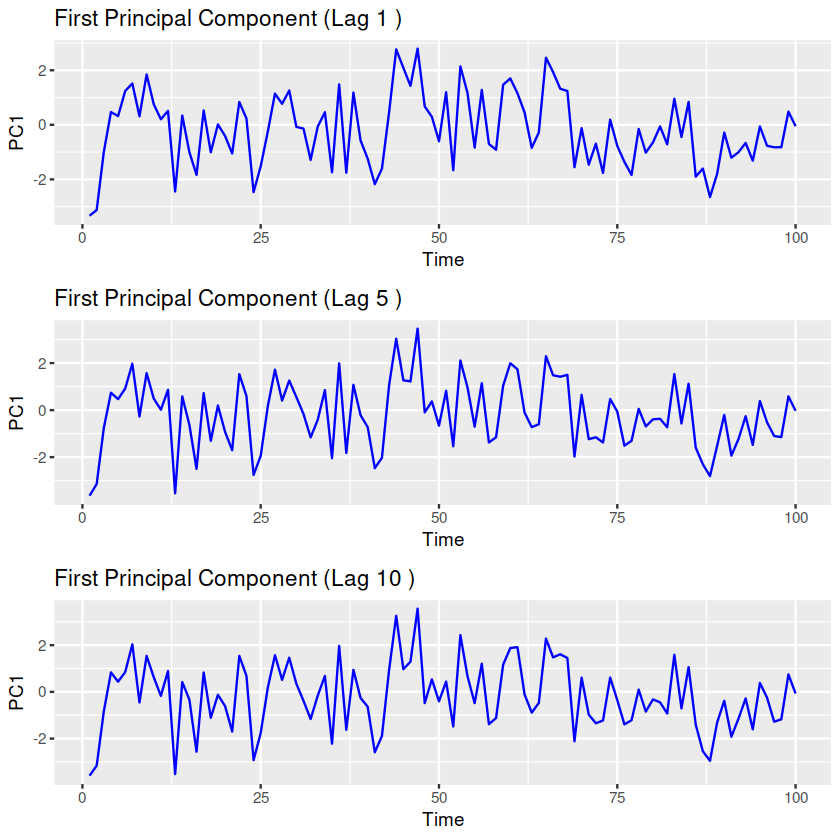

In [34]:
# Load necessary libraries
if (!require(freqdom)) {
  install.packages("freqdom")
}
library(freqdom)

# Step 1: Generate a synthetic VAR(1) process using the 'rar' function from the package
n <- 100  # Number of observations
d <- 5    # Number of variables (dimensionality)

# Generate a VAR(1) process using the built-in 'rar' function
data <- rar(n, d)

# Step 2: Apply Dynamic PCA with different lags and calculate explained variance
run_dpca_analysis <- function(data_matrix, q) {
  print(paste("Running DPCA with", q, "lags..."))
  
  # Try applying the DPCA function and check for errors
  dpca_result <- tryCatch({
    dpca(data_matrix, q = q, Ndpc = min(d, n))
  }, error = function(e) {
    print(paste("Error during DPCA computation:", e))
    return(NULL)
  })
  
  # Check if DPCA computation was successful
  if (is.null(dpca_result)) {
    print("DPCA computation failed.")
    return(NULL)
  }
  
  # Print the structure of the DPCA result for debugging
  print(str(dpca_result))
  
  # Calculate the explained variance using dpca.var()
  explained_variance <- dpca.var(dpca_result$spec.density)[1]
  
  return(list(dpca_result = dpca_result, explained_variance = explained_variance))
}

# Step 3: Run DPCA with lags 1, 5, and 10 and compare explained variance
lags <- c(1, 5, 10)
results <- list()

for (lag in lags) {
  result <- run_dpca_analysis(data, lag)
  if (!is.null(result)) {
    results[[paste("Lag", lag, sep = "_")]] <- result
  }
}

# Step 4: Print the explained variance for each lag
cat("\nExplained Variance for each Lag:\n")
for (lag in lags) {
  if (!is.null(results[[paste("Lag", lag, sep = "_")]])) {
    cat(paste("Lag", lag, ": ", results[[paste("Lag", lag, sep = "_")]]$explained_variance, "\n"))
  }
}

# Step 5: Visualize the first dynamic principal component for each lag
plot_first_pc <- function(dpca_result, lag) {
  # Extract the first dynamic principal component scores
  first_pc <- dpca_result$scores[, 1]
  
  # Check if first_pc is valid before plotting
  if (length(first_pc) > 0) {
    df <- data.frame(Time = 1:length(first_pc), PC1 = first_pc)
    p <- ggplot(df, aes(x = Time, y = PC1)) +
      geom_line(color = "blue") +
      labs(title = paste("First Principal Component (Lag", lag, ")"),
           x = "Time", y = "PC1")
    return(p)
  } else {
    cat("No valid data for first principal component at Lag", lag, "\n")
    return(NULL)
  }
}

# Step 6: Create the plots for all lags
library(ggplot2)
library(gridExtra)

plots <- lapply(lags, function(lag) {
  if (!is.null(results[[paste("Lag", lag, sep = "_")]])) {
    plot_first_pc(results[[paste("Lag", lag, sep = "_")]]$dpca_result, lag)
  }
})

# Filter out NULL plots (in case there were no valid principal components)
valid_plots <- Filter(Negate(is.null), plots)

# Display the plots side-by-side if there are any valid plots
if (length(valid_plots) > 0) {
  grid.arrange(grobs = valid_plots, ncol = 1)
} else {
  cat("No valid principal component data to plot.")
}


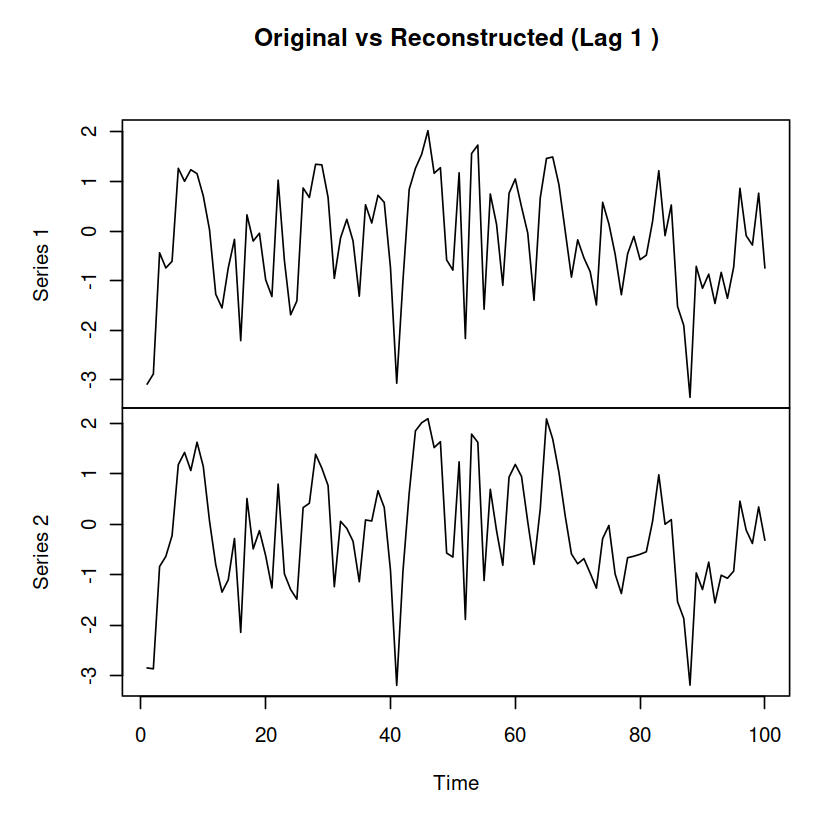

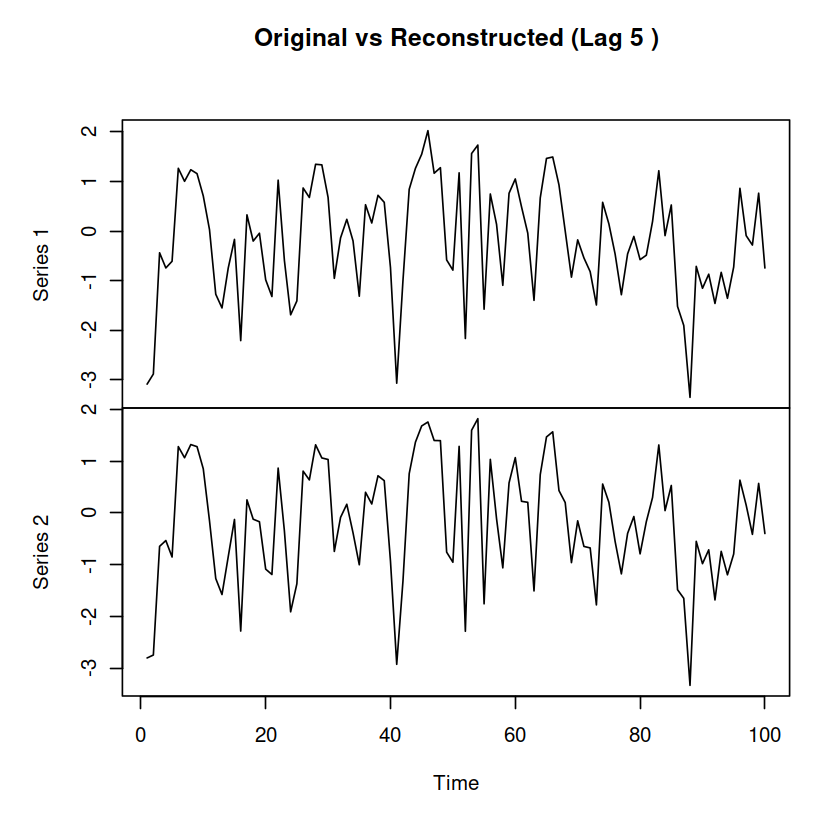

ERROR: Error in q <= 0: comparison (<=) is possible only for atomic and list types


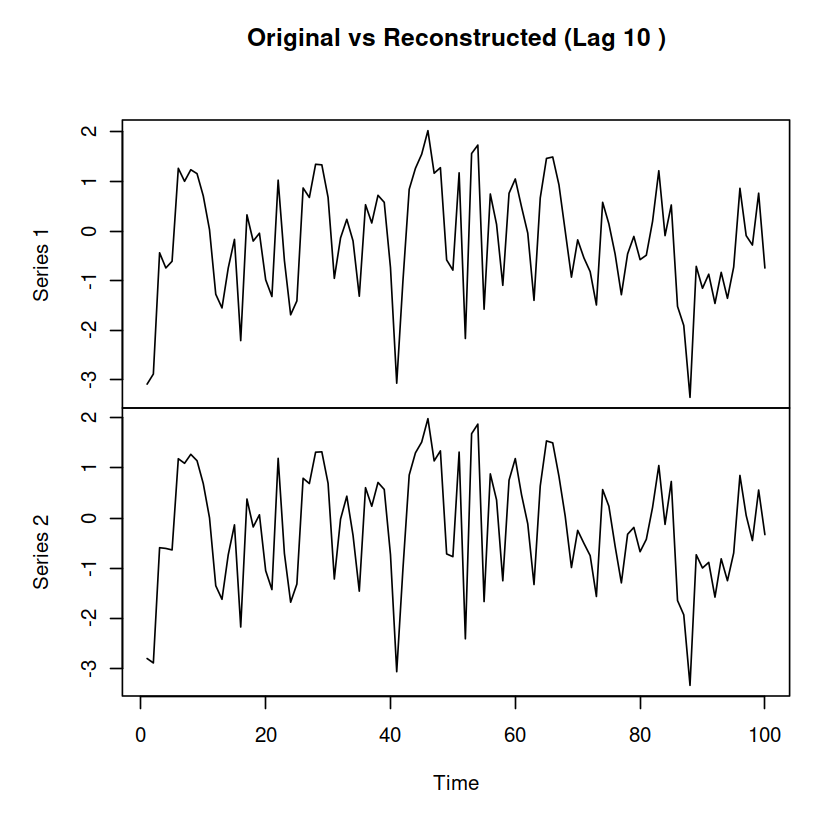

In [35]:
run_dpca_analysis <- function(data_matrix, q) {
  print(paste("Running DPCA with", q, "lags..."))
  dpca_result <- dpca(data_matrix, q = q, Ndpc = min(d, n))
  explained_variance <- dpca.var(dpca_result$spec.density)[1]
  return(list(dpca_result = dpca_result, explained_variance = explained_variance))
}
plot_first_pc <- function(dpca_result, lag) {
  first_pc <- dpca_result$scores[, 1]
  df <- data.frame(Time = 1:length(first_pc), PC1 = first_pc)
  ggplot(df, aes(x = Time, y = PC1)) +
    geom_line(color = "blue") +
    labs(title = paste("First Principal Component (Lag", lag, ")"),
         x = "Time", y = "PC1")
}
for (lag in lags) {
  dpca_result <- results[[paste("Lag", lag, sep = "_")]]$dpca_result
  original_data <- data  # Use your original data matrix here
  reconstructed_data <- dpca_result$Xhat
  
  # Plot comparison
  plot.ts(cbind(original_data[, 1], reconstructed_data[, 1]), col = c("black", "red"),
          main = paste("Original vs Reconstructed (Lag", lag, ")"))
}
dpca_result <- dpca(data_matrix, q = q, Ndpc = 2)  # Extract 2 principal components
explained_variance <- dpca.var(dpca_result$spec.density)[1:2]  # Check the explained variance for the first two components


In [37]:
# Load necessary libraries
library(ggplot2)
library(gridExtra)


In [40]:
# Function to explore the content of a DPCA result file
explore_dpca_result <- function(result_file) {
  # Load the DPCA result from the file
  dpca_result <- tryCatch({
    readRDS(result_file)
  }, error = function(e) {
    print(paste("Error loading result file:", e))
    return(NULL)
  })
  
  if (is.null(dpca_result)) {
    print(paste("No valid DPCA result for", result_file))
    return(NULL)
  }
  
  # Explore the contents
  print(paste("Exploring DPCA result for:", result_file))
  
  # Check the structure of the result
  str(dpca_result)
  
  # Check the scores (first principal component)
  if (!is.null(dpca_result$scores)) {
    cat("Dimensions of scores (Principal Components):\n")
    print(dim(dpca_result$scores))
    
    cat("Preview of first few rows of scores:\n")
    print(head(dpca_result$scores))
    
    # Explained variance (if available)
    if (!is.null(dpca_result$var)) {
      cat("Explained variance for each component:\n")
      print(dpca_result$var)
    } else {
      print("No explained variance data found.")
    }
  } else {
    print("No scores data found in DPCA result.")
  }
}

# Explore the results for each lag
explore_dpca_result("dpca_result_lag1.rds")
explore_dpca_result("dpca_result_lag5.rds")
explore_dpca_result("dpca_result_lag10.rds")
explore_dpca_result("dpca_result_lag365.rds")


[1] "Exploring DPCA result for: dpca_result_lag1.rds"
List of 3
 $ dpca_result       :List of 5
  ..$ spec.density:List of 2
  .. ..$ operators: cplx [1:17, 1:17, 1:2001] 0.039294-4.93e-32i 0.000268+7.69e-18i 0.032833+7.72e-19i ...
  .. .. ..- attr(*, "dimnames")=List of 3
  .. .. .. ..$ : NULL
  .. .. .. ..$ : NULL
  .. .. .. ..$ : chr [1:2001] "frequency -3.14159265358979" "frequency -3.1384510609362" "frequency -3.13530946828261" "frequency -3.13216787562902" ...
  .. ..$ freq     : num [1:2001] -3.14 -3.14 -3.14 -3.13 -3.13 ...
  .. ..- attr(*, "class")= chr "freqdom"
  ..$ filters     :List of 2
  .. ..$ operators: num [1, 1:17, 1:3] 0.000815 -0.004798 0.000394 0.004112 0.004862 ...
  .. .. ..- attr(*, "dimnames")=List of 3
  .. .. .. ..$ : NULL
  .. .. .. ..$ : NULL
  .. .. .. ..$ : chr [1:3] "lag -1" "lag 0" "lag 1"
  .. ..$ lags     : int [1:3] -1 0 1
  .. ..- attr(*, "class")= chr "timedom"
  ..$ scores      : num [1:15706, 1] 0.739 0.771 0.797 0.822 0.845 ...
  ..$ var       

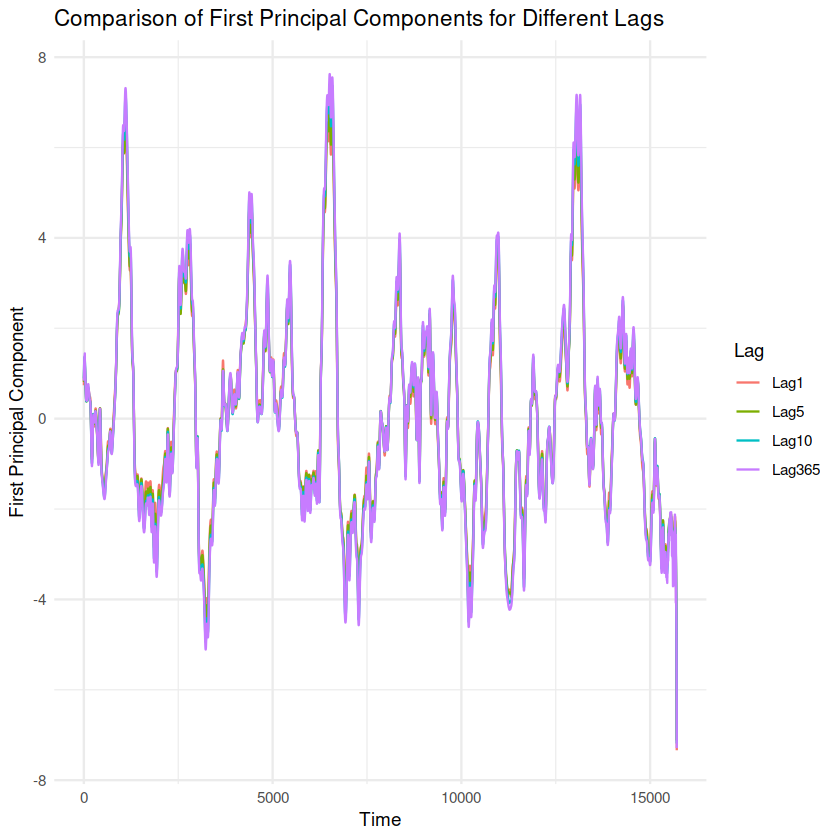

In [41]:
# Load required libraries for plotting
library(ggplot2)

# Function to plot the first principal component for a given lag
plot_first_pc <- function(first_pc, lag) {
  df <- data.frame(Time = 1:length(first_pc), PC1 = first_pc)
  ggplot(df, aes(x = Time, y = PC1)) +
    geom_line() +
    ggtitle(paste("First Principal Component - Lag", lag)) +
    xlab("Time") +
    ylab("First Principal Component")
}

# Load DPCA results for different lags
dpca_result_lag1 <- readRDS("dpca_result_lag1.rds")
dpca_result_lag5 <- readRDS("dpca_result_lag5.rds")
dpca_result_lag10 <- readRDS("dpca_result_lag10.rds")
dpca_result_lag365 <- readRDS("dpca_result_lag365.rds")

# Extract the first principal components for each lag
first_pc_lag1 <- dpca_result_lag1$first_pc
first_pc_lag5 <- dpca_result_lag5$first_pc
first_pc_lag10 <- dpca_result_lag10$first_pc
first_pc_lag365 <- dpca_result_lag365$first_pc

# Combine all first principal components into a data frame
df_all <- data.frame(
  Time = 1:length(first_pc_lag1),
  Lag1 = first_pc_lag1,
  Lag5 = first_pc_lag5,
  Lag10 = first_pc_lag10,
  Lag365 = first_pc_lag365
)

# Melt the data frame for easier plotting with ggplot
library(reshape2)
df_melted <- melt(df_all, id.vars = "Time", variable.name = "Lag", value.name = "First_PC")

# Plot all first principal components on the same plot
ggplot(df_melted, aes(x = Time, y = First_PC, color = Lag)) +
  geom_line() +
  ggtitle("Comparison of First Principal Components for Different Lags") +
  xlab("Time") +
  ylab("First Principal Component") +
  theme_minimal()


In [1]:
# Load necessary libraries
if (!require(gdpc)) {
  install.packages("gdpc")
}
library(gdpc)
library(readr)

# Load the data, excluding the Date column
data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv")

# Convert data to matrix form (excluding the Date column)
data_matrix <- as.matrix(data[,-1])

# Get the Date column for time stamps
time_stamps <- data$Date

# Standardize the data (optional, depending on the analysis)
data_standardized <- scale(data_matrix)

# Load GDPC results for different lags
gdpc_result_lag1 <- readRDS("/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_result_lag365.rds")

# Extract the first principal component (first factor) for each lag
gdpc_pc1_lag1 <- gdpc_result_lag1$f
gdpc_pc1_lag5 <- gdpc_result_lag5$f
gdpc_pc1_lag10 <- gdpc_result_lag10$f
gdpc_pc1_lag365 <- gdpc_result_lag365$f

# Create a data frame to store the results
gdpc_components_df <- data.frame(
  Date = time_stamps,
  GDPC_Lag1 = gdpc_pc1_lag1,
  GDPC_Lag5 = gdpc_pc1_lag5,
  GDPC_Lag10 = gdpc_pc1_lag10,
  GDPC_Lag365 = gdpc_pc1_lag365
)

# Save the data frame to a CSV file in the specified directory
write.csv(gdpc_components_df, "/data/muscat_data/jaguir26/project1_ucsc_phd/gdpc_first_components.csv", row.names = FALSE)

cat("CSV file with the first components and time stamps saved successfully.\n")

# Plot the components using ggplot
if (!require(ggplot2)) {
  install.packages("ggplot2")
}
library(ggplot2)
library(reshape2)

# Assuming the `Lag` column in gdpc_components_melted has the old labels (e.g., "GDPC_Lag1", "GDPC_Lag5", etc.),
# we'll first modify the Lag column to use the new labels for plotting.

gdpc_components_melted$Lag <- factor(gdpc_components_melted$Lag, 
                                     levels = c("GDPC_Lag1", "GDPC_Lag5", "GDPC_Lag10", "GDPC_Lag365"),
                                     labels = c("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)"))

# Plot with the updated labels and solid lines
ggplot(gdpc_components_melted, aes(x = Date, y = First_PC, color = Lag)) +
  geom_line(size = 1.2) +
  scale_color_manual(values = c("GDPC AR(1)" = "#1b9e77", "GDPC AR(5)" = "#d95f02", 
                                "GDPC AR(10)" = "#7570b3", "GDPC AR(365)" = "#e7298a")) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "Comparison of GDPC First Principal Components for Different Lags",
    x = "Time",
    y = "First Principal Component"
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE))  # Organize the legend in a neat manner



Loading required package: gdpc

Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


CSV file with the first components and time stamps saved successfully.


Loading required package: ggplot2



ERROR: Error in eval(expr, envir, enclos): object 'gdpc_components_melted' not found


Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 16679 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (1): Daily_Avg_Log_Streamflow
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.


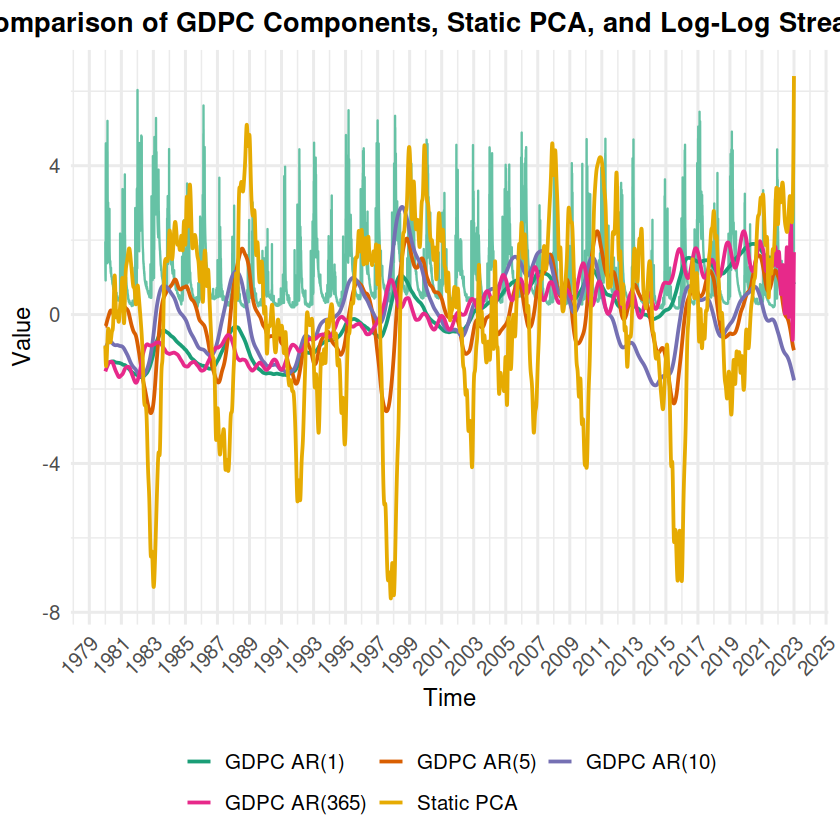

In [4]:
# Load necessary libraries
if (!require(gdpc)) {
  install.packages("gdpc")
}
library(gdpc)
library(readr)
library(ggplot2)
library(reshape2)

# Load the GDPC components file
data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv")

# Convert data to matrix form (excluding the Date column)
data_matrix <- as.matrix(data[,-1])

# Get the Date column for time stamps
time_stamps <- data$Date

# Standardize the data (optional, depending on the analysis)
data_standardized <- scale(data_matrix)

# Perform static PCA on the standardized data
pca_result <- prcomp(data_standardized, scale. = TRUE)

# Extract the first principal component (PC1) from the PCA result
static_pca_pc1 <- pca_result$x[, 1]  # First principal component

# Load GDPC results for different lags
gdpc_result_lag1 <- readRDS("gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("gdpc_result_lag365.rds")

# Extract the first principal component (first factor) for each lag
gdpc_pc1_lag1 <- gdpc_result_lag1$f
gdpc_pc1_lag5 <- gdpc_result_lag5$f
gdpc_pc1_lag10 <- gdpc_result_lag10$f
gdpc_pc1_lag365 <- gdpc_result_lag365$f

# Check the lengths to ensure they match with the time stamps
if (length(gdpc_pc1_lag1) != length(time_stamps)) {
  stop("The length of the first principal component for Lag 1 does not match the time stamps.")
}

if (length(gdpc_pc1_lag5) != length(time_stamps)) {
  stop("The length of the first principal component for Lag 5 does not match the time stamps.")
}

if (length(gdpc_pc1_lag10) != length(time_stamps)) {
  stop("The length of the first principal component for Lag 10 does not match the time stamps.")
}

if (length(gdpc_pc1_lag365) != length(time_stamps)) {
  stop("The length of the first principal component for Lag 365 does not match the time stamps.")
}

# Load the USGS daily average streamflow data
usgs_data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/usgs_daily_avg.csv")

# Compute the logarithm of the streamflow data (if it's not already log-transformed)
usgs_data$Log_Log_Streamflow <- (usgs_data$Daily_Avg_Log_Streamflow)

# Merge the GDPC components, static PCA, and USGS data on the Date column
combined_data <- data.frame(
  Date = time_stamps,
  GDPC_Lag1 = gdpc_pc1_lag1,
  GDPC_Lag5 = gdpc_pc1_lag5,
  GDPC_Lag10 = gdpc_pc1_lag10,
  GDPC_Lag365 = gdpc_pc1_lag365,
  Static_PCA = static_pca_pc1
)

# Merge in the USGS streamflow data
combined_data <- merge(combined_data, usgs_data[, c("Date", "Log_Log_Streamflow")], by = "Date", all.x = TRUE)

# Melt the combined data for plotting
combined_data_melted <- melt(combined_data, id.vars = "Date", variable.name = "Series", value.name = "Value")

# Update labels for GDPC components, static PCA, and USGS time series
combined_data_melted$Series <- factor(combined_data_melted$Series, 
                                      levels = c("GDPC_Lag1", "GDPC_Lag5", "GDPC_Lag10", "GDPC_Lag365", "Static_PCA", "Log_Log_Streamflow"),
                                      labels = c("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)", "Static PCA", "Log-Log Streamflow"))

# Plot the combined data with GDPC components, Static PCA, and Log-Log Streamflow
ggplot(combined_data_melted, aes(x = Date, y = Value, color = Series)) +
  geom_line(data = combined_data_melted[combined_data_melted$Series == "Log-Log Streamflow",], 
            aes(x = Date, y = Value), size = 0.5, color = "#66c2a5") +  # Thin solid line for Log-Log Streamflow in the background
  geom_line(data = combined_data_melted[combined_data_melted$Series != "Log-Log Streamflow",], size = 0.8) +  # Solid thicker lines for GDPC components and Static PCA
  scale_color_manual(values = c("GDPC AR(1)" = "#1b9e77", "GDPC AR(5)" = "#d95f02", 
                                "GDPC AR(10)" = "#7570b3", "GDPC AR(365)" = "#e7298a", 
                                "Static PCA" = "#e6ab02", "Log-Log Streamflow" = "#66c2a5")) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "Comparison of GDPC Components, Static PCA, and Log-Log Streamflow",
    x = "Time",
    y = "Value"
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE))  # Organize the legend in a neat manner


Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Rows: 16679 Columns: 2
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (1): Daily_Avg_Log_Streamflow
date (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
Warning message:
“Removed 15706 rows containing missing values or values outside the scale range
(`geom_line()`).”


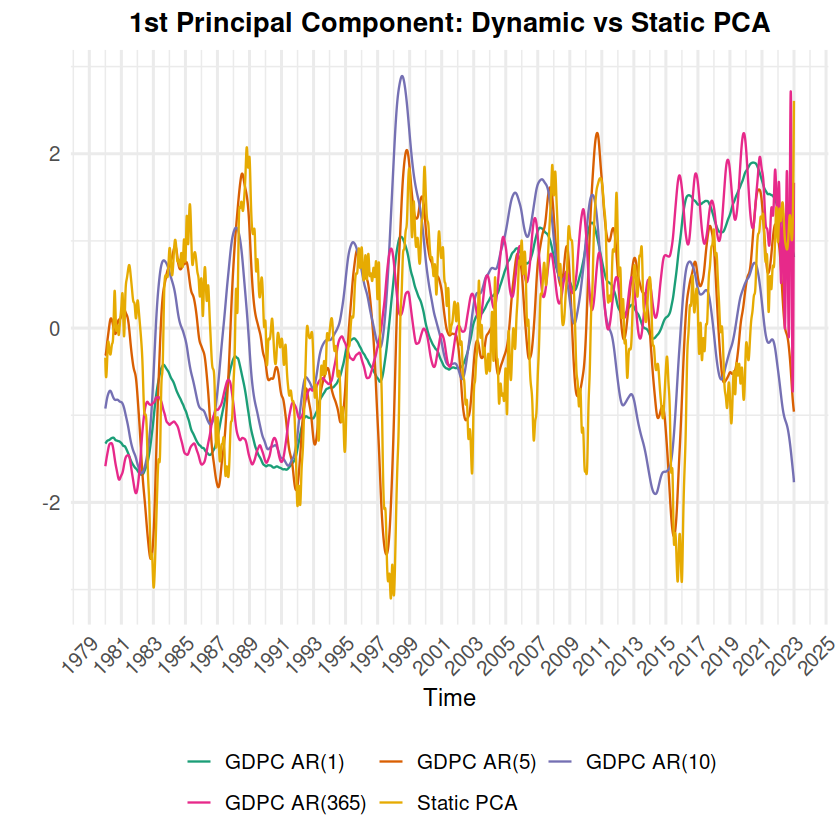

In [14]:
# Load necessary libraries
if (!require(gdpc)) {
  install.packages("gdpc")
}
library(gdpc)
library(readr)
library(ggplot2)
library(reshape2)

# Load the GDPC components file
data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv")

# Convert data to matrix form (excluding the Date column)
data_matrix <- as.matrix(data[,-1])

# Get the Date column for time stamps
time_stamps <- data$Date

# Standardize the data (optional, depending on the analysis)
data_standardized <- scale(data_matrix)

# Perform static PCA on the standardized data
pca_result <- prcomp(data_standardized, scale. = TRUE)

# Extract the first principal component (PC1) from the PCA result
static_pca_pc1 <- pca_result$x[, 1]  # First principal component

# Load GDPC results for different lags
gdpc_result_lag1 <- readRDS("gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("gdpc_result_lag365.rds")

# Extract the first principal component (first factor) for each lag
gdpc_pc1_lag1 <- gdpc_result_lag1$f
gdpc_pc1_lag5 <- gdpc_result_lag5$f
gdpc_pc1_lag10 <- gdpc_result_lag10$f
gdpc_pc1_lag365 <- gdpc_result_lag365$f

# Load the USGS daily average streamflow data
usgs_data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/usgs_daily_avg.csv")

# Compute the logarithm of the streamflow data (if it's not already log-transformed)
usgs_data$Log_Log_Streamflow <- 0*log(usgs_data$Daily_Avg_Log_Streamflow)

# Merge the GDPC components, static PCA, and USGS data on the Date column
combined_data <- data.frame(
  Date = time_stamps,
  GDPC_Lag1 = gdpc_pc1_lag1,
  GDPC_Lag5 = gdpc_pc1_lag5,
  GDPC_Lag10 = gdpc_pc1_lag10,
  GDPC_Lag365 = gdpc_pc1_lag365,
  Static_PCA = static_pca_pc1
)

# Merge in the USGS streamflow data
combined_data <- merge(combined_data, usgs_data[, c("Date", "Log_Log_Streamflow")], by = "Date", all.x = TRUE)

# Standardize each time series (excluding the Date column)
combined_data[, -1] <- scale(combined_data[, -1])

# Melt the combined data for plotting
# combined_data_melted <- melt(combined_data, id.vars = "Date", variable.name = "Series", value.name = "Value")
combined_data_melted <- melt(combined_data, id.vars = "Date", variable.name = "Series", value.name = "Value")


# Update labels for GDPC components, static PCA, and USGS time series
combined_data_melted$Series <- factor(combined_data_melted$Series, 
                                      levels = c("GDPC_Lag1", "GDPC_Lag5", "GDPC_Lag10", "GDPC_Lag365", "Static_PCA", "Log_Log_Streamflow"),
                                      labels = c("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)", "Static PCA", "Log-Log Streamflow"))

# Plot the standardized time series with GDPC components, Static PCA, and Log-Log Streamflow
ggplot(combined_data_melted, aes(x = Date, y = Value, color = Series)) +
  geom_line(data = combined_data_melted[combined_data_melted$Series == "Log-Log Streamflow",], 
            aes(x = Date, y = Value), size = 0.5, color = "#66c2a5") +  # Thin solid line for Log-Log Streamflow in the background
  geom_line(data = combined_data_melted[combined_data_melted$Series != "Log-Log Streamflow",], size = 0.5) +  # Solid thicker lines for GDPC components and Static PCA
  scale_color_manual(values = c("GDPC AR(1)" = "#1b9e77", "GDPC AR(5)" = "#d95f02", 
                                "GDPC AR(10)" = "#7570b3", "GDPC AR(365)" = "#e7298a", 
                                "Static PCA" = "#e6ab02", "Log-Log Streamflow" = "#66c2a5")) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "1st Principal Component: Dynamic vs Static PCA",
    x = "Time",
    y = " "
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE))  # Organize the legend in a neat manner


In [17]:
# Load necessary libraries
if (!require(gdpc)) {
  install.packages("gdpc")
}
library(gdpc)
library(readr)
library(ggplot2)
library(reshape2)

# Load the GDPC components file
data <- read_csv("/data/muscat_data/jaguir26/project1_ucsc_phd/climate_indices/combined_indices_daily.csv")

# Convert data to matrix form (excluding the Date column)
data_matrix <- as.matrix(data[,-1])

# Get the Date column for time stamps
time_stamps <- data$Date

# Standardize the data (optional, depending on the analysis)
data_standardized <- scale(data_matrix)

# Perform static PCA on the standardized data
pca_result <- prcomp(data_standardized, scale. = TRUE)

# Extract the first principal component (PC1) from the PCA result
static_pca_pc1 <- pca_result$x[, 1]  # First principal component

# Load GDPC results for different lags
gdpc_result_lag1 <- readRDS("gdpc_result_lag1.rds")
gdpc_result_lag5 <- readRDS("gdpc_result_lag5.rds")
gdpc_result_lag10 <- readRDS("gdpc_result_lag10.rds")
gdpc_result_lag365 <- readRDS("gdpc_result_lag365.rds")

# Extract the first principal component (first factor) for each lag
gdpc_pc1_lag1 <- gdpc_result_lag1$f
gdpc_pc1_lag5 <- gdpc_result_lag5$f
gdpc_pc1_lag10 <- gdpc_result_lag10$f
gdpc_pc1_lag365 <- gdpc_result_lag365$f

# Create a data frame to store the standardized PCA results
combined_data <- data.frame(
  Date = time_stamps,
  GDPC_Lag1 = scale(gdpc_pc1_lag1),
  GDPC_Lag5 = scale(gdpc_pc1_lag5),
  GDPC_Lag10 = scale(gdpc_pc1_lag10),
  GDPC_Lag365 = scale(gdpc_pc1_lag365),
  Static_PCA = scale(static_pca_pc1)
)

# Melt the combined data for plotting
combined_data_melted <- melt(combined_data, id.vars = "Date", variable.name = "Series", value.name = "Value")

# Update labels for GDPC components and Static PCA
combined_data_melted$Series <- factor(combined_data_melted$Series, 
                                      levels = c("GDPC_Lag1", "GDPC_Lag5", "GDPC_Lag10", "GDPC_Lag365", "Static_PCA"),
                                      labels = c("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)", "Static PCA"))

# Define consistent color mapping for each time series
color_mapping <- c("GDPC AR(1)" = "#1b9e77", "GDPC AR(5)" = "#d95f02", 
                   "GDPC AR(10)" = "#7570b3", "GDPC AR(365)" = "#e7298a", 
                   "Static PCA" = "#e6ab02")

# Plot 1: All PCAs (Dynamic and Static) in one plot
p1 <- ggplot(combined_data_melted, aes(x = Date, y = Value, color = Series)) +
  geom_line(size = 0.8) +
  scale_color_manual(values = color_mapping) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "All Dynamic and Static Principal Components",
    x = "Time",
    y = "Standardized Value"
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE))

# Plot 2: Only Static PCA
p2 <- ggplot(combined_data_melted[combined_data_melted$Series == "Static PCA",], 
             aes(x = Date, y = Value, color = Series)) +
  geom_line(size = 0.8) +
  scale_color_manual(values = color_mapping["Static PCA"]) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "Static Principal Component",
    x = "Time",
    y = "Standardized Value"
  )

# Plot 3: Only Dynamic PCAs
p3 <- ggplot(combined_data_melted[combined_data_melted$Series != "Static PCA",], 
             aes(x = Date, y = Value, color = Series)) +
  geom_line(size = 0.8) +
  scale_color_manual(values = color_mapping[c("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)")]) +
  scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
  theme_minimal(base_size = 14) + 
  theme(
    plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
    legend.title = element_blank(),
    legend.position = "bottom",
    legend.text = element_text(size = 12),
    axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
    axis.text.y = element_text(size = 12),
    axis.title = element_text(size = 14)
  ) +
  labs(
    title = "Dynamic Principal Components",
    x = "Time",
    y = "Standardized Value"
  ) +
  guides(color = guide_legend(nrow = 2, byrow = TRUE))

# Plot 4: Individual Dynamic PCAs with Static PCA
dynamic_pca_list <- list("GDPC AR(1)", "GDPC AR(5)", "GDPC AR(10)", "GDPC AR(365)")
individual_plots <- list()

for (pca_name in dynamic_pca_list) {
  individual_plots[[pca_name]] <- ggplot(combined_data_melted[combined_data_melted$Series %in% c(pca_name, "Static PCA"),], 
                                         aes(x = Date, y = Value, color = Series)) +
    geom_line(size = 0.8) +
    scale_color_manual(values = color_mapping[c(pca_name, "Static PCA")]) +
    scale_x_date(date_labels = "%Y", date_breaks = "2 years") +
    theme_minimal(base_size = 14) + 
    theme(
      plot.title = element_text(hjust = 0.5, face = "bold", size = 16),
      legend.title = element_blank(),
      legend.position = "bottom",
      legend.text = element_text(size = 12),
      axis.text.x = element_text(angle = 45, hjust = 1, size = 12),
      axis.text.y = element_text(size = 12),
      axis.title = element_text(size = 14)
    ) +
    labs(
      title = paste0(pca_name, " vs Static PCA"),
      x = "Time",
      y = "Standardized Value"
    )
}

# Save the plots in high quality
ggsave("plot1_all_pcas.png", plot = p1, width = 10, height = 6, dpi = 300)
ggsave("plot2_static_pca.png", plot = p2, width = 10, height = 6, dpi = 300)
ggsave("plot3_dynamic_pcas.png", plot = p3, width = 10, height = 6, dpi = 300)

for (pca_name in dynamic_pca_list) {
  ggsave(paste0("plot4_", pca_name, "_vs_static.png"), plot = individual_plots[[pca_name]], width = 10, height = 6, dpi = 300)
}


Rows: 15706 Columns: 18
── Column specification ────────────────────────────────────────────────────────
Delimiter: ","
dbl  (17): Niño 3, NAO, Niño 1+2, WHWP, GMT, ONI, PNA, NOI, WP, Niño 3.4, So...
date  (1): Date

ℹ Use `spec()` to retrieve the full column specification for this data.
ℹ Specify the column types or set `show_col_types = FALSE` to quiet this message.
